In [125]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors
import torch.nn as nn
import torch.optim as optim
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [126]:
import torch
import random

torch.manual_seed(42)
random.seed(42)

In [127]:
#Build train/test split and dataloader
def get_data_loader(
    data_dir="/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
    image_size=(128,128),
    batch_size=32
):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(
        root=data_dir,
        transform=transform
    )

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    
    train_dataset, test_dataset = random_split(
        dataset,
        [train_size, test_size]
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    
    return train_loader, test_loader

In [128]:
train_loader, test_loader = get_data_loader()

In [129]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [130]:
print(len(train_loader.dataset))
print(len(test_loader.dataset))

4471
1118


In [131]:
#2 Build CNN for 128x128
import torch.nn as nn

class VehicleCNN(nn.Module):

    def __init__(self, image_size):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        feature_size = image_size // 8

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * feature_size * feature_size,
                128
            ),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [132]:
model = VehicleCNN(128)

print(model)

VehicleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [133]:
images, labels = next(iter(train_loader))

outputs = model(images)

print(outputs.shape)

torch.Size([32, 7])


In [134]:
print(outputs.shape)

torch.Size([32, 7])


In [135]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [136]:
num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5, Loss: 1.3171
Epoch 2/5, Loss: 0.8166
Epoch 3/5, Loss: 0.6558
Epoch 4/5, Loss: 0.4780
Epoch 5/5, Loss: 0.3485


In [137]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Test Accuracy: {accuracy:.2f}%"
)

Test Accuracy: 81.22%


In [138]:
def train_and_evaluate(image_size):

    train_loader, test_loader = get_data_loader(
        data_dir="/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
        image_size=(image_size, image_size)
    )

    model = VehicleCNN()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    num_epochs = 5

    for epoch in range(num_epochs):

        model.train()

        for images, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [139]:
#16x16

In [140]:
train_loader, test_loader = get_data_loader(
    "/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
    image_size=(16,16)
)

In [141]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([32, 3, 16, 16])


In [142]:
#CNN
import torch.nn as nn

class VehicleCNN(nn.Module):

    def __init__(self, image_size):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        feature_size = image_size // 8

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * feature_size * feature_size,
                128
            ),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [143]:
model = VehicleCNN(16)

In [146]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [147]:
num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5, Loss: 1.7651
Epoch 2/5, Loss: 1.4483
Epoch 3/5, Loss: 1.2815
Epoch 4/5, Loss: 1.1785
Epoch 5/5, Loss: 1.0821


In [148]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 60.47%


In [151]:
#32x32
train_loader, test_loader = get_data_loader(
    "/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
    image_size=(32,32)
)

In [152]:
import torch.nn as nn

class VehicleCNN(nn.Module):

    def __init__(self, image_size):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        feature_size = image_size // 8

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * feature_size * feature_size,
                128
            ),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [155]:
model = VehicleCNN(32)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [156]:
train_loader, test_loader = get_data_loader(
    "/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
    image_size=(32,32)
)

In [157]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([32, 3, 32, 32])


In [158]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [159]:
num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5, Loss: 1.7054
Epoch 2/5, Loss: 1.3284
Epoch 3/5, Loss: 1.1055
Epoch 4/5, Loss: 0.9968
Epoch 5/5, Loss: 0.8913


In [160]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 65.30%


In [161]:
#64x64

In [162]:
#new cnn
import torch.nn as nn

class VehicleCNN(nn.Module):

    def __init__(self, image_size):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        feature_size = image_size // 8

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * feature_size * feature_size,
                128
            ),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [163]:
#load 64x64 images
train_loader, test_loader = get_data_loader(
    "/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
    image_size=(64,64)
)

In [164]:
#new model
model = VehicleCNN(64)

In [165]:
# verify the size of image
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([32, 3, 64, 64])


In [166]:
#loss and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [167]:
#train
num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5, Loss: 1.5221
Epoch 2/5, Loss: 0.9893
Epoch 3/5, Loss: 0.7913
Epoch 4/5, Loss: 0.6362
Epoch 5/5, Loss: 0.5239


In [171]:
#evaluate
model = VehicleCNN(64)

train_loader, test_loader = get_data_loader(
    "/gpfs/home/lwhite5/my-dl-project/src/my_dl_project/dl_project/Vehicles",
    image_size=(64,64)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 80.05%


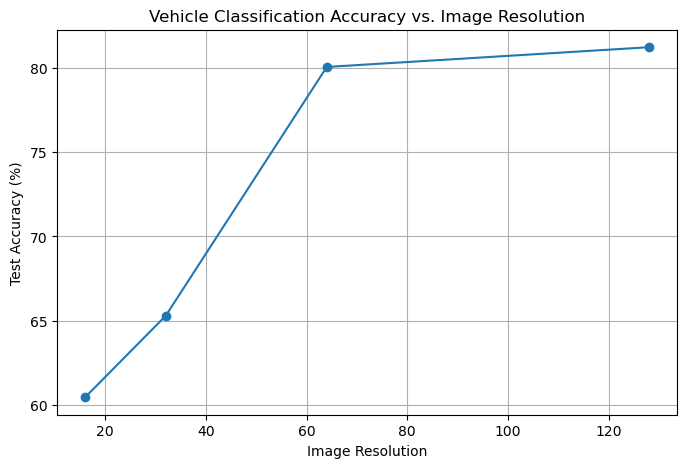

In [172]:
import matplotlib.pyplot as plt

resolutions = [16, 32, 64, 128]
accuracies = [60.47, 65.30, 80.05, 81.22]

plt.figure(figsize=(8,5))
plt.plot(resolutions, accuracies, marker="o")
plt.xlabel("Image Resolution")
plt.ylabel("Test Accuracy (%)")
plt.title("Vehicle Classification Accuracy vs. Image Resolution")
plt.grid(True)

plt.show()